# Local-convolutional Hebbian model demo

A gradient-free (pure numpy) model run on the drift task.

- **Input layer** `[n_input, 2]`: two channels per position -- the stimulus `s`
  and its complement `1 - s`.
- **Hidden layer** `[n_input, n_channels]`: driven by a **local convolution**
  from the input and a **local convolutional recurrence** from the hidden layer.

    h(t+1) = tau * h(t) + (1 - tau) * sigmoid(W_in * I + W_h * h)

Weights are non-negative, learned by a **correlational (Hebbian) rule** and
renormalized each step. There are no gradients. Below: the architecture and
learning-rule schematics, then input & hidden activities before vs. after
training.


## Hyperparameters

All model, task, and training knobs in one place.

In [91]:
# ---- Hyperparameters ----
# model
N          = 24     # n_input: number of spatial positions (stimulus length)
N_CHANNELS = 6      # hidden channels per position
KERNEL     = 5      # local conv kernel size (odd)
TAU        = 0.6    # hidden timeconstant
ACT_SLOPE     = 0.5  # activation: INITIAL slope (per-neuron, adapts for homeostasis)
ACT_THRESHOLD = 1.0  # activation: input value where it saturates (flat above)
TARGET_RATE   = 0.4  # homeostatic target mean firing rate
SLOPE_LR      = 0.02 # rate of per-neuron activation-slope adaptation
NORM_IN    = 1.0    # input->hidden per-presynaptic weight-sum normalization
NORM_H     = 1.0    # recurrent per-presynaptic weight-sum normalization
LR_IN      = 0.05    # input->hidden additive Hebbian learning rate
LR_H       = 0.05    # recurrent additive Hebbian learning rate
WEIGHT_DECAY = 0.005  # fraction each weight is pulled toward its neuron's mean weight (0 = off)
MEAN_RATE  = 0.02   # EMA rate for the running-mean firing rates
SEED       = 0

# task / demo
PROB            = 0.3    # drift Bernoulli probability
VIEW_STEPS      = 150    # length of the sequence we visualize
N_EPOCHS        = 60     # training epochs
STEPS_PER_EPOCH = 200    # steps per training sequence

In [92]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Rectangle, FancyBboxPatch

from tasks import DriftTask
from models import LocalConvHebbianModel

## Architecture schematic

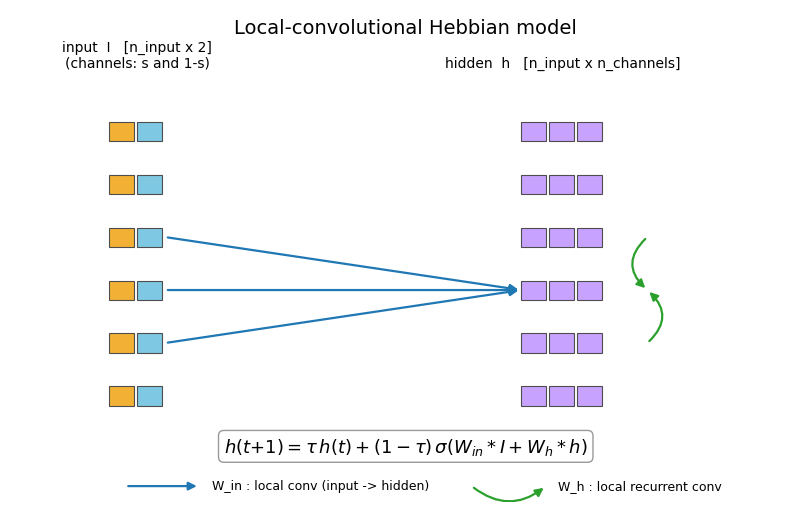

In [93]:
def draw_architecture():
    n_pos, n_ch = 6, 3
    x_in, x_hid = 0.0, 5.0
    cw = 0.34                      # channel-cell width
    p = n_pos // 2                 # highlighted target position

    fig, ax = plt.subplots(figsize=(10, 6.4))
    ax.axis('off')
    ax.set_xlim(-1.2, 8.2)
    ax.set_ylim(-2.0, n_pos + 1.3)

    in_col = {'s': '#f2b134', 'c': '#7ec8e3'}   # stimulus / complement channels
    hid_col = '#c8a2ff'

    def row_y(i):
        return n_pos - 1 - i

    in_centers, hid_centers = [], []
    for i in range(n_pos):
        y = row_y(i)
        for c, col in enumerate(in_col.values()):
            ax.add_patch(Rectangle((x_in + c * cw, y - 0.18), cw * 0.9, 0.36,
                                    facecolor=col, edgecolor='0.3', lw=0.8))
        in_centers.append((x_in + cw, y))
        for c in range(n_ch):
            ax.add_patch(Rectangle((x_hid + c * cw, y - 0.18), cw * 0.9, 0.36,
                                    facecolor=hid_col, edgecolor='0.3', lw=0.8))
        hid_centers.append((x_hid + n_ch * cw / 2, y))

    for q in (p - 1, p, p + 1):
        ax.add_patch(FancyArrowPatch(
            (in_centers[q][0] + cw, in_centers[q][1]),
            (hid_centers[p][0] - n_ch * cw / 2, hid_centers[p][1]),
            arrowstyle='-|>', mutation_scale=12, color='#1f77b4', lw=1.6))
    for q in (p - 1, p + 1):
        ax.add_patch(FancyArrowPatch(
            (hid_centers[q][0] + n_ch * cw, hid_centers[q][1]),
            (hid_centers[p][0] + n_ch * cw, hid_centers[p][1]),
            arrowstyle='-|>', mutation_scale=12, color='#2ca02c', lw=1.6,
            connectionstyle='arc3,rad=0.55'))

    ax.text(3.6, n_pos + 0.95, 'Local-convolutional Hebbian model',
            ha='center', va='center', fontsize=14)
    ax.text(x_in + cw, n_pos + 0.15, 'input  I   [n_input x 2]\n(channels: s and 1-s)',
            ha='center', va='bottom', fontsize=10)
    ax.text(x_hid + n_ch * cw / 2, n_pos + 0.15, 'hidden  h   [n_input x n_channels]',
            ha='center', va='bottom', fontsize=10)

    ax.text(3.6, -0.95,
            r'$h(t{+}1) = \tau\,h(t) + (1-\tau)\,\sigma(W_{in}*I + W_h*h)$',
            ha='center', va='center', fontsize=13,
            bbox=dict(boxstyle='round', fc='white', ec='0.6'))

    ax.add_patch(FancyArrowPatch((0.2, -1.7), (1.1, -1.7), arrowstyle='-|>',
                                 mutation_scale=12, color='#1f77b4', lw=1.6))
    ax.text(1.25, -1.7, 'W_in : local conv (input -> hidden)', va='center', fontsize=9)
    ax.add_patch(FancyArrowPatch((4.4, -1.7), (5.3, -1.7), arrowstyle='-|>',
                                 mutation_scale=12, color='#2ca02c', lw=1.6,
                                 connectionstyle='arc3,rad=0.4'))
    ax.text(5.45, -1.7, 'W_h : local recurrent conv', va='center', fontsize=9)
    plt.show()

draw_architecture()


## Learning-rule schematic

Applied to every weight, every step -- no gradients.

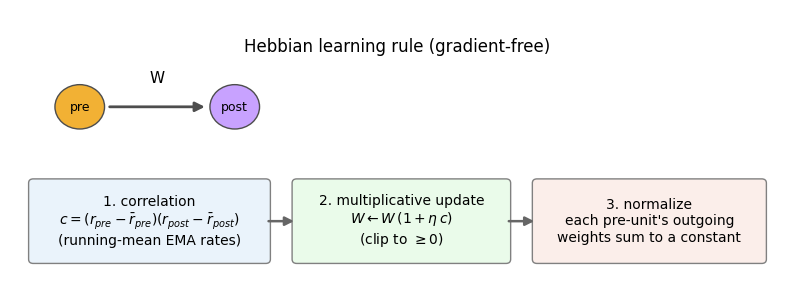

In [94]:
def draw_learning_rule():
    fig, ax = plt.subplots(figsize=(10, 3.6))
    ax.axis('off')
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 4)

    # pre -> post with weight
    ax.add_patch(plt.Circle((0.9, 2.6), 0.32, fc='#f2b134', ec='0.3'))
    ax.text(0.9, 2.6, 'pre', ha='center', va='center', fontsize=9)
    ax.add_patch(plt.Circle((2.9, 2.6), 0.32, fc='#c8a2ff', ec='0.3'))
    ax.text(2.9, 2.6, 'post', ha='center', va='center', fontsize=9)
    ax.add_patch(FancyArrowPatch((1.25, 2.6), (2.55, 2.6), arrowstyle='-|>',
                                 mutation_scale=14, color='0.3', lw=2))
    ax.text(1.9, 2.95, 'W', ha='center', fontsize=11)

    def box(x, y, w, h, text, fc):
        ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.06',
                                    fc=fc, ec='0.5'))
        ax.text(x + w / 2, y + h / 2, text, ha='center', va='center', fontsize=10)

    box(0.3, 0.4, 3.0, 1.1,
        '1. correlation\n' r'$c=(r_{pre}-\bar r_{pre})(r_{post}-\bar r_{post})$'
        '\n(running-mean EMA rates)', '#eaf3fb')
    box(3.7, 0.4, 2.7, 1.1,
        '2. multiplicative update\n' r'$W \leftarrow W\,(1+\eta\,c)$' '\n(clip to $\\geq 0$)', '#eafbea')
    box(6.8, 0.4, 2.9, 1.1,
        '3. normalize\n' 'each pre-unit\'s outgoing\nweights sum to a constant', '#fbeeea')

    for x0, x1 in [(3.3, 3.7), (6.4, 6.8)]:
        ax.add_patch(FancyArrowPatch((x0, 0.95), (x1, 0.95), arrowstyle='-|>',
                                     mutation_scale=13, color='0.4', lw=1.8))
    ax.text(5.0, 3.4, 'Hebbian learning rule (gradient-free)', ha='center', fontsize=12)
    plt.show()

draw_learning_rule()

## Activation function

The hidden nonlinearity is clipped-linear: zero for inputs <= 0, rising with slope `ACT_SLOPE`, then flat at `ACT_SLOPE * ACT_THRESHOLD` for inputs above `ACT_THRESHOLD`.

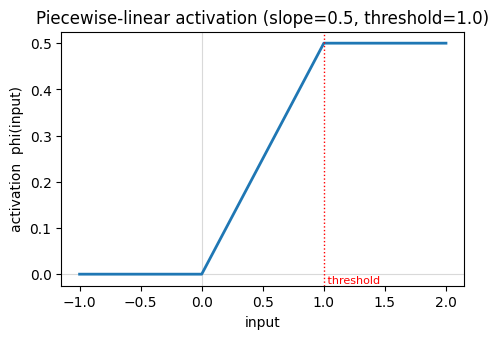

In [95]:
xs = np.linspace(-1.0, 2.0 * ACT_THRESHOLD, 400)
ys = np.clip(ACT_SLOPE * xs, 0.0, ACT_SLOPE * ACT_THRESHOLD)

fig, ax = plt.subplots(figsize=(5.2, 3.3))
ax.plot(xs, ys, lw=2)
ax.axhline(0, color='0.85', lw=0.8, zorder=0)
ax.axvline(0, color='0.85', lw=0.8, zorder=0)
ax.axvline(ACT_THRESHOLD, color='r', ls=':', lw=1)
ax.text(ACT_THRESHOLD, ax.get_ylim()[0], ' threshold', color='r', ha='left', va='bottom', fontsize=8)
ax.set_xlabel('input')
ax.set_ylabel('activation  phi(input)')
ax.set_title(f'Piecewise-linear activation (slope={ACT_SLOPE}, threshold={ACT_THRESHOLD})')
plt.show()

## Setup, and a plotting helper for activities

In [96]:
task = DriftTask(vector_length=N, prob=PROB)
model = LocalConvHebbianModel(n_input=N, n_channels=N_CHANNELS, kernel_size=KERNEL,
                              tau=TAU, act_slope=ACT_SLOPE, act_threshold=ACT_THRESHOLD,
                              target_rate=TARGET_RATE, slope_lr=SLOPE_LR,
                              norm_in=NORM_IN, norm_h=NORM_H,
                              lr_in=LR_IN, lr_h=LR_H, weight_decay=WEIGHT_DECAY,
                              mean_rate=MEAN_RATE, seed=SEED)

def plot_activities(I_seq, h_seq, title):
    C = h_seq.shape[2]
    fig, axes = plt.subplots(1 + C, 1, figsize=(9.4, 1.25 * (1 + C)), sharex=True)
    im0 = axes[0].imshow(I_seq[:, :, 0].T, aspect='auto', cmap='viridis',
                         vmin=0, vmax=1, interpolation='nearest')
    axes[0].set_ylabel('input s', rotation=0, ha='right', va='center')
    fig.colorbar(im0, ax=axes[0], label='stimulus')
    for c in range(C):
        im = axes[c + 1].imshow(h_seq[:, :, c].T, aspect='auto', cmap='magma',
                                vmin=0, vmax=1, interpolation='nearest')
        axes[c + 1].set_ylabel(f'h ch{c}', rotation=0, ha='right', va='center')
        fig.colorbar(im, ax=axes[c + 1], label='rate')
    axes[-1].set_xlabel('timestep')
    axes[0].set_title(title)
    plt.tight_layout()
    plt.show()

view_stim = task.generate(VIEW_STEPS, seed=1234)   # fixed sequence for before/after comparison

## Before training

Untrained (random) weights, learning off. The hidden channels respond to the drifting input but without learned structure.

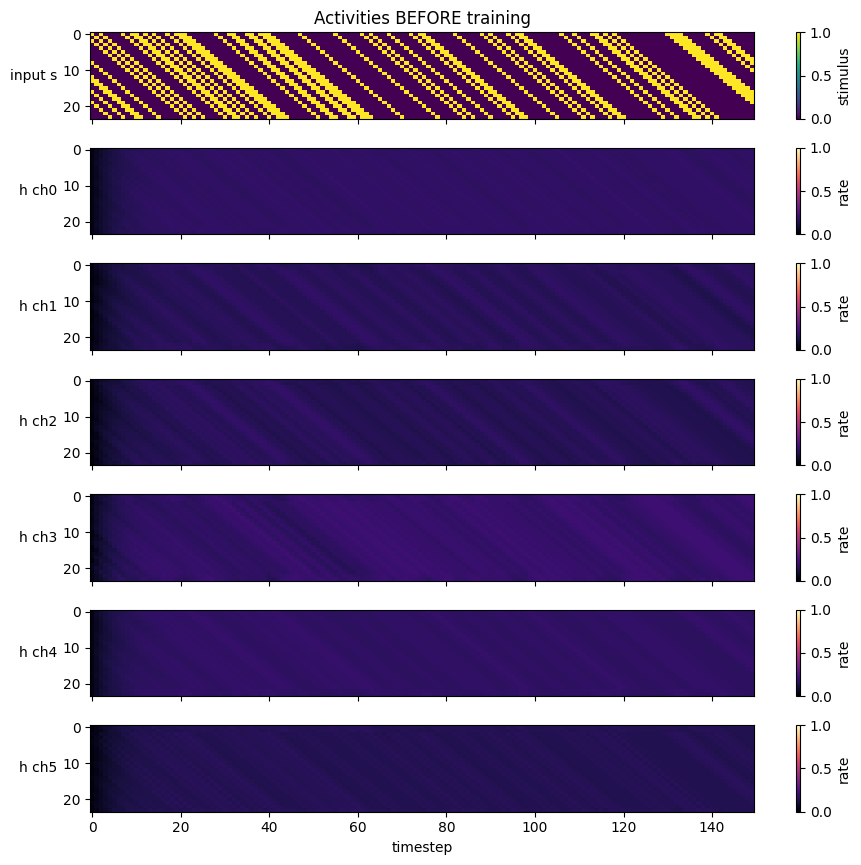

In [97]:
model.reset()
I_before, h_before = model.run(view_stim, learn=False)
W_in_before, W_h_before = model.W_in.copy(), model.W_h.copy()
plot_activities(I_before, h_before, 'Activities BEFORE training')

## Train

Run the Hebbian rule over many drift sequences (learning on).

In [98]:
for ep in range(N_EPOCHS):
    model.run(task.generate(STEPS_PER_EPOCH, seed=1000 + ep), learn=True)
print('training done; weight normalization preserved:',
      np.allclose(model.W_in.sum(axis=(0, 2)), model.norm_in),
      np.allclose(model.W_h.sum(axis=(0, 2)), model.norm_h))

training done; weight normalization preserved: True True


## After training

Same input sequence, learning off. Compare the hidden activity to the untrained model above.

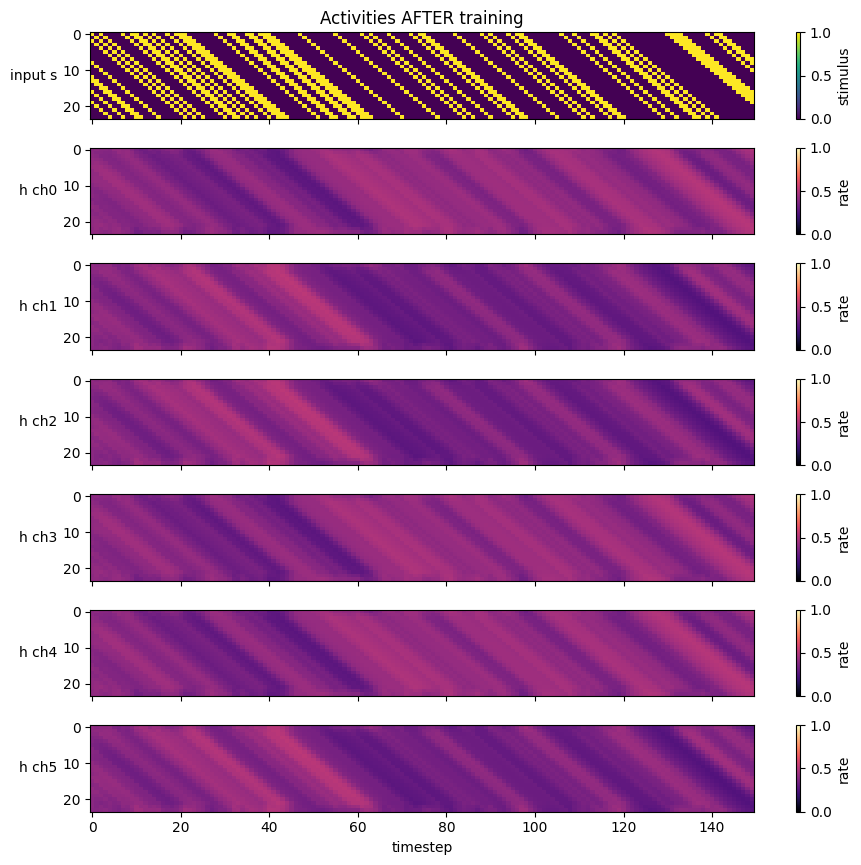

mean |h_after - h_before| = 0.223


In [99]:
model.reset()
I_after, h_after = model.run(view_stim, learn=False)
plot_activities(I_after, h_after, 'Activities AFTER training')
print('mean |h_after - h_before| =', round(float(np.abs(h_after - h_before).mean()), 4))

## Homeostasis: firing rates and adapted activations

Each neuron adapts its activation slope to hold the target mean rate, so none stay silent. Per-neuron mean rates before vs. after training (target marked), and the spread of adapted per-neuron activation functions.

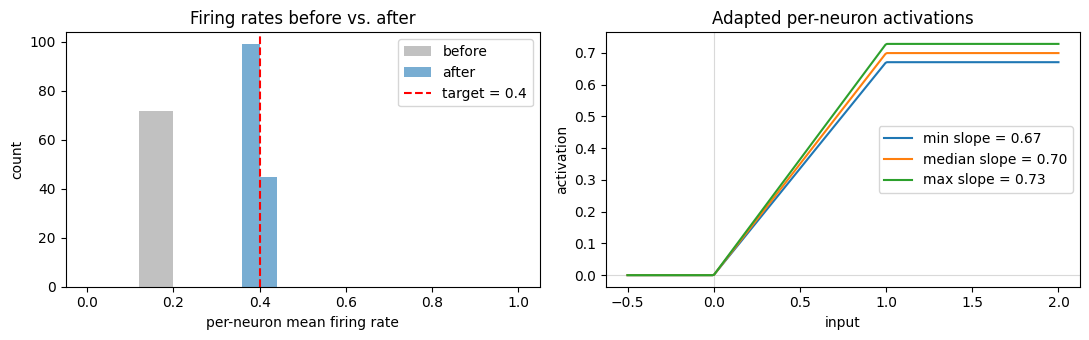

silent neurons (rate < 0.02): before 0%, after 0%


In [100]:
rate_before = h_before.mean(axis=0).ravel()   # per-neuron mean rate over time
rate_after  = h_after.mean(axis=0).ravel()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
bins = np.linspace(0, 1, 26)
axes[0].hist(rate_before, bins=bins, alpha=0.6, color='0.6', label='before')
axes[0].hist(rate_after,  bins=bins, alpha=0.6, color='C0', label='after')
axes[0].axvline(TARGET_RATE, color='r', ls='--', lw=1.5, label=f'target = {TARGET_RATE}')
axes[0].set_xlabel('per-neuron mean firing rate'); axes[0].set_ylabel('count')
axes[0].set_title('Firing rates before vs. after'); axes[0].legend()

slopes = model.act_slope.ravel()
xs = np.linspace(-0.5, 2.0 * ACT_THRESHOLD, 300)
for s, lab in [(slopes.min(), 'min'), (np.median(slopes), 'median'), (slopes.max(), 'max')]:
    axes[1].plot(xs, np.clip(s * xs, 0.0, s * ACT_THRESHOLD), label=f'{lab} slope = {s:.2f}')
axes[1].axhline(0, color='0.85', lw=0.8, zorder=0); axes[1].axvline(0, color='0.85', lw=0.8, zorder=0)
axes[1].set_xlabel('input'); axes[1].set_ylabel('activation')
axes[1].set_title('Adapted per-neuron activations'); axes[1].legend()
plt.tight_layout(); plt.show()

print('silent neurons (rate < 0.02): before %.0f%%, after %.0f%%'
      % (100 * (rate_before < 0.02).mean(), 100 * (rate_after < 0.02).mean()))

## What the recurrent weights learned

The recurrent kernel `W_h` is indexed by spatial offset (pre position - post
position). Rightward drift means activity at position `p` came from `p-1` one step
earlier, so the correlational rule should build up weight at **offset -1**. Below,
the offset mass of `W_h` before vs. after training.


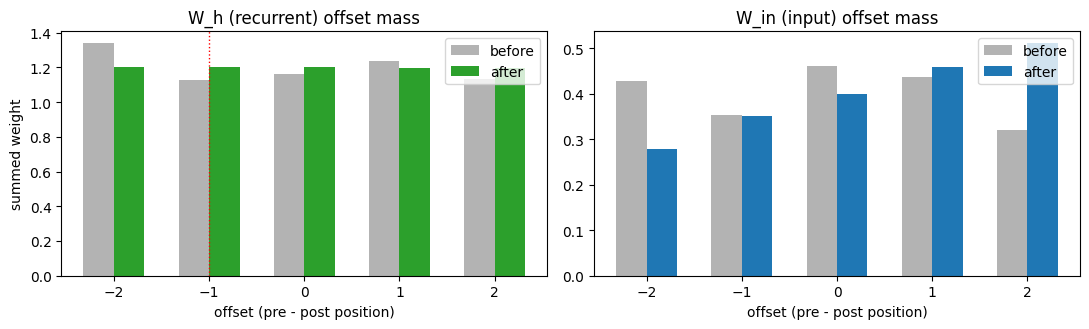

In [101]:
offsets = np.arange(-model.center, model.center + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].bar(offsets - 0.16, W_h_before.sum(axis=(1, 2)), width=0.32, label='before', color='0.7')
axes[0].bar(offsets + 0.16, model.W_h.sum(axis=(1, 2)), width=0.32, label='after', color='#2ca02c')
axes[0].axvline(-1, color='r', ls=':', lw=1)
axes[0].set_title('W_h (recurrent) offset mass')
axes[0].set_xlabel('offset (pre - post position)'); axes[0].set_ylabel('summed weight'); axes[0].legend()

axes[1].bar(offsets - 0.16, W_in_before.sum(axis=(1, 2)), width=0.32, label='before', color='0.7')
axes[1].bar(offsets + 0.16, model.W_in.sum(axis=(1, 2)), width=0.32, label='after', color='#1f77b4')
axes[1].set_title('W_in (input) offset mass')
axes[1].set_xlabel('offset (pre - post position)'); axes[1].legend()
plt.tight_layout()
plt.show()

## Weight distributions and matrices

Histograms of all weights (before vs. after training), then the actual kernels shown as images.

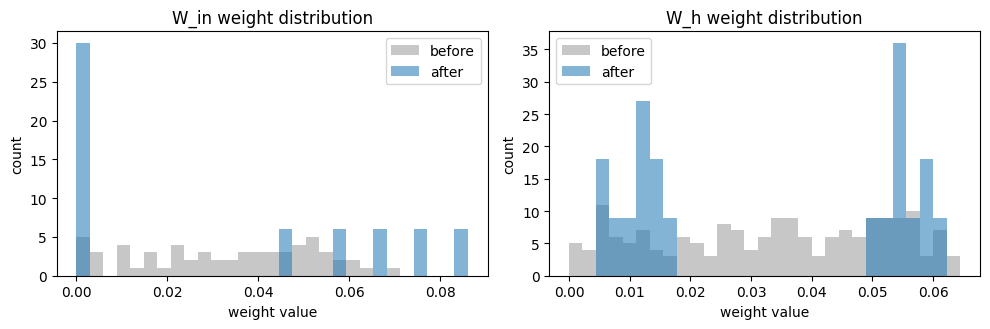

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, Wb, Wa, name in [(axes[0], W_in_before, model.W_in, 'W_in'),
                         (axes[1], W_h_before, model.W_h, 'W_h')]:
    bins = np.linspace(0, max(Wb.max(), Wa.max()), 30)
    ax.hist(Wb.ravel(), bins=bins, alpha=0.55, label='before', color='0.6')
    ax.hist(Wa.ravel(), bins=bins, alpha=0.55, label='after', color='C0')
    ax.set_title(f'{name} weight distribution')
    ax.set_xlabel('weight value'); ax.set_ylabel('count'); ax.legend()
plt.tight_layout()
plt.show()

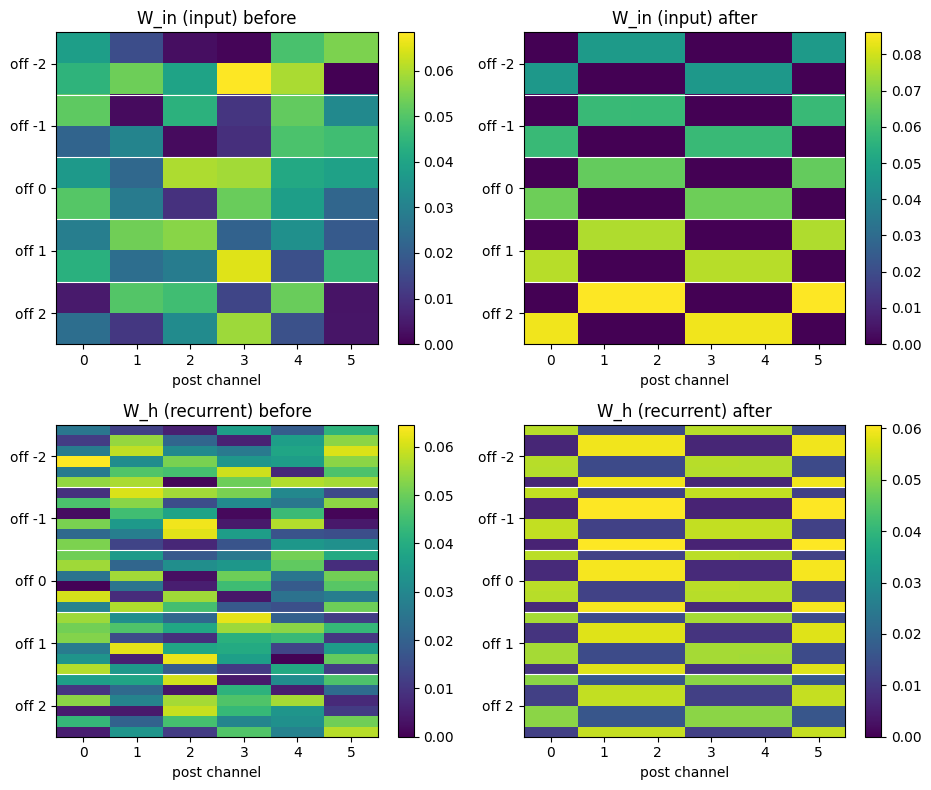

In [103]:
# Kernels [K, C_pre, C_post] flattened to a [K*C_pre, C_post] image.
# Rows are grouped by spatial offset (dashed lines); the y-tick per group is the offset.
offsets = np.arange(-model.center, model.center + 1)

def show_kernel(ax, W, title):
    K, Cpre, Cpost = W.shape
    im = ax.imshow(W.reshape(K * Cpre, Cpost), aspect='auto', cmap='viridis',
                   vmin=0, interpolation='nearest')
    for k in range(1, K):
        ax.axhline(k * Cpre - 0.5, color='w', lw=0.8)
    ax.set_yticks([k * Cpre + (Cpre - 1) / 2 for k in range(K)])
    ax.set_yticklabels([f'off {o}' for o in offsets])
    ax.set_xlabel('post channel'); ax.set_title(title)
    fig.colorbar(im, ax=ax)

fig, axes = plt.subplots(2, 2, figsize=(9.5, 8))
show_kernel(axes[0, 0], W_in_before, 'W_in (input) before')
show_kernel(axes[0, 1], model.W_in, 'W_in (input) after')
show_kernel(axes[1, 0], W_h_before, 'W_h (recurrent) before')
show_kernel(axes[1, 1], model.W_h, 'W_h (recurrent) after')
plt.tight_layout()
plt.show()

## Receptive fields

For each hidden channel, the local pattern (over the kernel window) that maximally
and minimally drives it. Because weights are non-negative, "max/min" is meaningful
under the model's per-position normalization:

- **Input**: each position is the complementary pair `(s, 1-s)` summing to 1, so
  the maximally-activating stimulus is `s = 1` wherever the `s`-weight exceeds the
  `(1-s)`-weight (and `s = 0` elsewhere); the min-activating input is the complement.
- **Recurrent**: applying the same per-position (sum-to-1 over channels)
  normalization, the maximally-activating recurrent state puts all activity, at
  each offset, on the pre-synaptic channel with the largest weight (min: smallest).

Offsets are `pre - post` position; a strong entry at offset `-1` = tuned to
rightward motion.


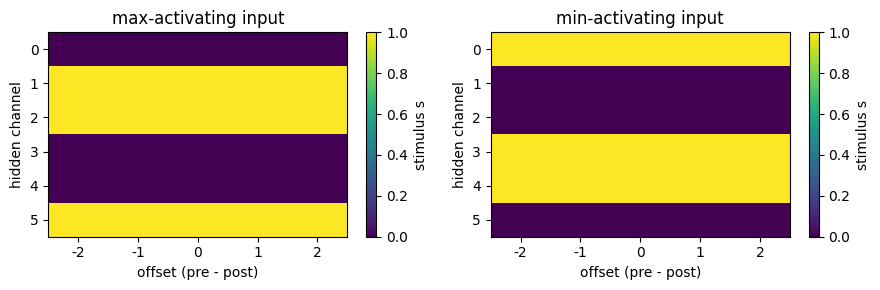

In [104]:
offsets = np.arange(-model.center, model.center + 1)
K, C = model.kernel_size, model.n_channels

# --- input receptive fields ---
pref = model.W_in[:, 0, :] - model.W_in[:, 1, :]   # s vs (1-s) preference, [K, C]
max_stim = (pref >= 0).astype(float).T             # [C, K], stimulus value in {0,1}
min_stim = 1.0 - max_stim

fig, axes = plt.subplots(1, 2, figsize=(9, 3.0))
for ax, data, name in [(axes[0], max_stim, 'max-activating input'),
                       (axes[1], min_stim, 'min-activating input')]:
    im = ax.imshow(data, aspect='auto', cmap='viridis', vmin=0, vmax=1, interpolation='nearest')
    ax.set_xticks(range(K)); ax.set_xticklabels(offsets)
    ax.set_xlabel('offset (pre - post)'); ax.set_ylabel('hidden channel')
    ax.set_title(name)
    fig.colorbar(im, ax=ax, label='stimulus s')
plt.tight_layout()
plt.show()

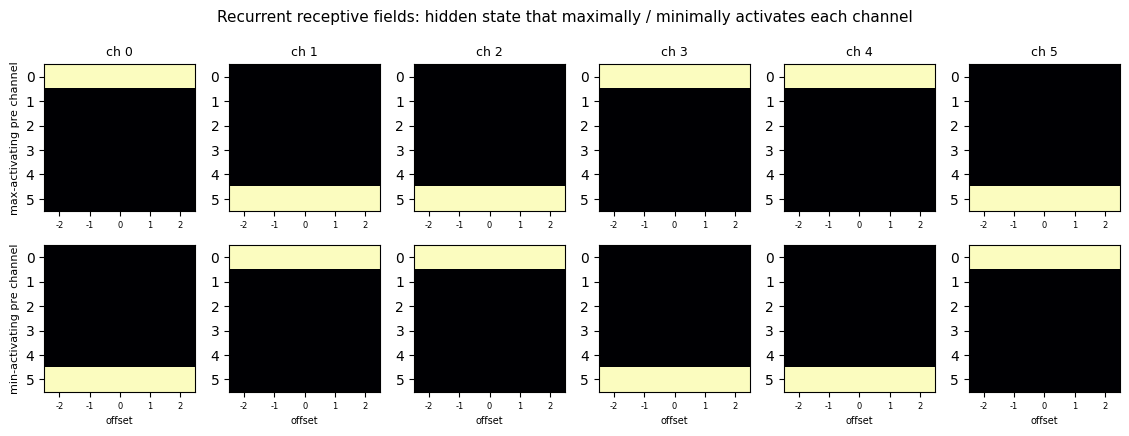

In [105]:
# --- recurrent receptive fields ---
# For each post channel c: at each offset, the pre channel that most / least drives it.
def extreme_state(argfn):
    out = np.zeros((C, C, K))   # [post channel, pre channel, offset]
    for c in range(C):
        for k in range(K):
            out[c, argfn(model.W_h[k, :, c]), k] = 1.0
    return out

max_state = extreme_state(np.argmax)
min_state = extreme_state(np.argmin)

fig, axes = plt.subplots(2, C, figsize=(1.9 * C, 4.4))
for c in range(C):
    for r, (data, label) in enumerate([(max_state, 'max'), (min_state, 'min')]):
        ax = axes[r][c]
        ax.imshow(data[c], aspect='auto', cmap='magma', vmin=0, vmax=1, interpolation='nearest')
        ax.set_xticks(range(K)); ax.set_xticklabels(offsets, fontsize=6)
        ax.set_yticks(range(C))
        if r == 0:
            ax.set_title(f'ch {c}', fontsize=9)
        else:
            ax.set_xlabel('offset', fontsize=7)
        if c == 0:
            ax.set_ylabel(f'{label}-activating pre channel', fontsize=8)
fig.suptitle('Recurrent receptive fields: hidden state that maximally / minimally activates each channel', fontsize=11)
plt.tight_layout()
plt.show()
